# Implementing MLPs with Keras

In [ ]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist
X_train,y_train = X_train_full[:-5000],y_train_full[:-5000]
X_valid,y_valid = X_train_full[-5000:],y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(55000, 28, 28)

In [ ]:
X_train.dtype

dtype('uint8')

In [ ]:
X_train,X_valid,X_test = X_train / 255.,X_valid / 255.,X_test / 255.

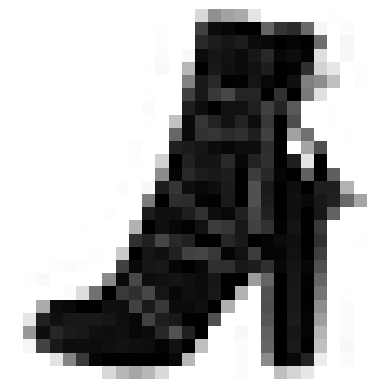

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[11],cmap='binary')
plt.axis('off')
plt.show()

In [ ]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

In [ ]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

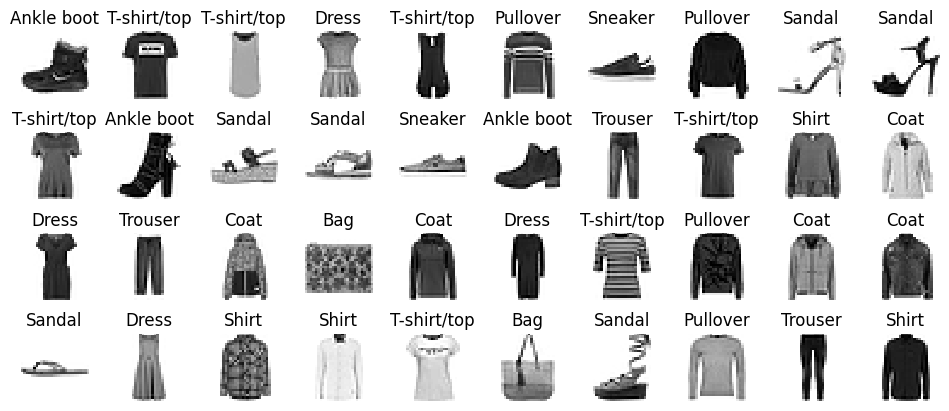

In [ ]:
n_rows=4
n_cols=10
plt.figure(figsize=(n_cols * 1.2,n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index=n_cols * row + col
        plt.subplot(n_rows,n_cols,index+1)
        plt.imshow(X_train[index],cmap='binary',interpolation='nearest')
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show();

# Tensorflow Sequential API

In [ ]:
tf.random.set_seed(42)
tf.keras.backend.clear_session()

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape = [28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300,activation='relu'))
model.add(tf.keras.layers.Dense(100,activation='relu'))
model.add(tf.keras.layers.Dense(10,activation='softmax'))


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

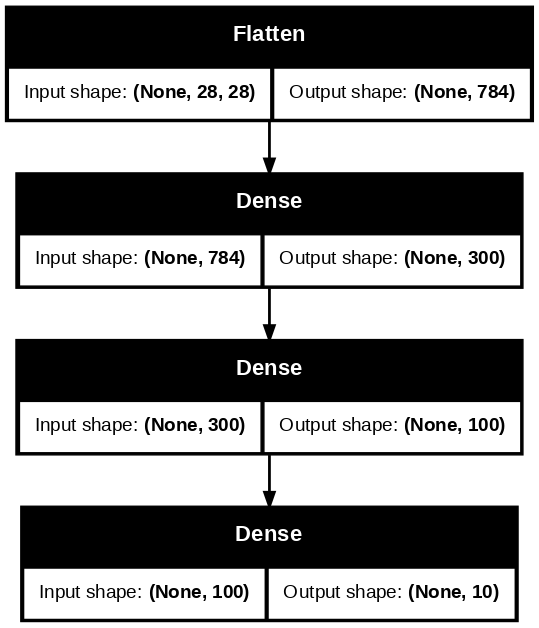

In [ ]:
tf.keras.utils.plot_model(model,show_shapes=True,dpi=100)

In [ ]:
tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [28,28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

In [ ]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [ ]:
hidden1=model.layers[1]
hidden1.name

'dense'

In [ ]:
model.get_layer('dense') is hidden1

True

In [ ]:
weights, biases = hidden1.get_weights()

In [ ]:
weights, biases

(array([[ 0.03614357, -0.00828725, -0.02577285, ...,  0.0076321 ,
         -0.0725372 ,  0.03421544],
        [-0.06705452, -0.02009035, -0.03706791, ..., -0.01842723,
          0.01864222, -0.03535891],
        [ 0.05386025, -0.05059183, -0.04677524, ...,  0.02482725,
         -0.02282081,  0.05936722],
        ...,
        [-0.02326797,  0.00329429,  0.00281627, ..., -0.01702121,
          0.06044792,  0.06091522],
        [ 0.04692074,  0.04287001, -0.07051372, ...,  0.0448309 ,
          0.019838  ,  0.04170817],
        [ 0.0281949 , -0.00287446, -0.02066972, ...,  0.01932965,
         -0.05615833,  0.0092141 ]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

# Compiling Model

In [ ]:
model.compile(
    loss='spare_categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [ ]:
model.compile(
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=[tf.keras.metrics.sparse_categorical_accuracy]
)

In [ ]:
tf.keras.utils.to_categorical([0,5,1,0],num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
import numpy as np

np.argmax(
       [
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]
       ],
        axis=1

)

array([0, 5, 1, 0])

# Fitting Model

In [ ]:
-np.log(1/10)

2.3025850929940455

In [ ]:
history=model.fit(X_train,y_train,epochs=5,
          validation_data=(X_valid, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3775 - sparse_categorical_accuracy: 0.8684 - val_loss: 0.3943 - val_sparse_categorical_accuracy: 0.8536
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3656 - sparse_categorical_accuracy: 0.8716 - val_loss: 0.3871 - val_sparse_categorical_accuracy: 0.8558
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.3546 - sparse_categorical_accuracy: 0.8754 - val_loss: 0.3813 - val_sparse_categorical_accuracy: 0.8604
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3447 - sparse_categorical_accuracy: 0.8779 - val_loss: 0.3761 - val_sparse_categorical_accuracy: 0.8622
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3355 - sparse_categorical_accuracy: 0.8808 - val_loss: 0.3712 - val_sparse_categorical_accuracy: 0.8648


In [ ]:
1719*32

55008

In [ ]:
history.history

{'loss': [0.37390515208244324,
  0.3617880046367645,
  0.35110482573509216,
  0.34142765402793884,
  0.3325689136981964],
 'sparse_categorical_accuracy': [0.868218183517456,
  0.8721272945404053,
  0.8755272626876831,
  0.8784182071685791,
  0.8817999958992004],
 'val_loss': [0.39430364966392517,
  0.38705775141716003,
  0.38130712509155273,
  0.3761003911495209,
  0.37120312452316284],
 'val_sparse_categorical_accuracy': [0.853600025177002,
  0.8557999730110168,
  0.8604000210762024,
  0.8622000217437744,
  0.864799976348877]}

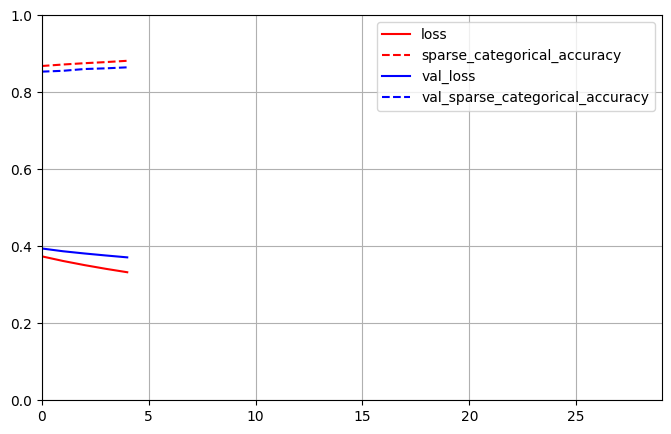

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8,5),xlim=[0,29],ylim=[0,1],grid=True,style=['r-','r--','b-','b--'],label=True)
plt.legend();

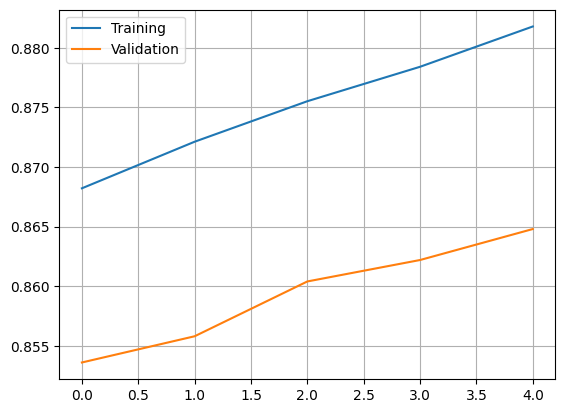

In [ ]:
plt.plot(history.history['sparse_categorical_accuracy'],label='Training')
plt.plot(history.history['val_sparse_categorical_accuracy'],label='Validation')
plt.legend()
plt.grid()
plt.show()

In [ ]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3975 - sparse_categorical_accuracy: 0.8609


[0.4015253782272339, 0.8579999804496765]

In [ ]:
X_new=X_test[:3]
probs=model.predict(X_new).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [ ]:
probs

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.24, 0.  , 0.06, 0.  , 0.7 ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
preds=np.argmax(probs,axis=1)
preds

array([9, 2, 1])

In [ ]:
np.array(class_names)[preds]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [ ]:
class_names[5]

'Sandal'

In [ ]:
y_new=y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

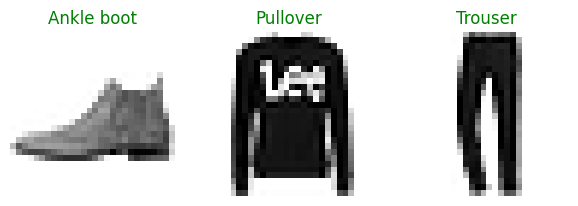

In [ ]:
plt.figure(figsize=(7.2,2.4))

for index, image in enumerate(X_new):
    plt.subplot(1,3, index+1)
    plt.imshow(image,cmap='binary',interpolation='nearest',)
    plt.axis('off')
    plt.title(class_names[y_new[index]],fontsize=12,color='g' if preds[index]==y_new[index] else 'r')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

# Regrsesion Model

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full,X_test,y_train_full,y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train,X_valid,y_train,y_valid = train_test_split(
    X_train_full,y_train_full,random_state=42
)

In [ ]:
norm_layer=tf.keras.layers.Normalization()
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape = X_train.shape[1:]),
    norm_layer,
    tf.keras.layers.Dense(30,activation='relu'),
    tf.keras.layers.Dense(30,activation='relu'),
    tf.keras.layers.Dense(1)
])

In [ ]:
norm_layer.adapt(X_train)
model.compile(
    loss='mse',
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics = ['RootMeanSquaredError']
)

model.fit(X_train,y_train,epochs=5,
          validation_data=(X_valid,y_valid))

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.1008 - loss: 1.2792 - val_RootMeanSquaredError: 2.3360 - val_loss: 5.4568
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7164 - loss: 0.5138 - val_RootMeanSquaredError: 1.7456 - val_loss: 3.0472
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6676 - loss: 0.4461 - val_RootMeanSquaredError: 1.2150 - val_loss: 1.4761
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6463 - loss: 0.4178 - val_RootMeanSquaredError: 2.3304 - val_loss: 5.4309
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6475 - loss: 0.4194 - val_RootMeanSquaredError: 0.8866 - val_loss: 0.7861


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ normalization (Normalization)        │ (None, 8)                   │              17 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │             270 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 30)                  │             930 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,250 (4.89 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[0.61775357]], dtype=float32)

# Functional API

In [ ]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1=tf.keras.layers.Dense(30,activation='relu')
hidden_layer2=tf.keras.layers.Dense(30,activation='relu')
concat_layer=tf.keras.layers.Concatenate()
output_layer=tf.keras.layers.Dense(1)

input_=tf.keras.layers.Input(shape=[8])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model=tf.keras.Model(inputs=[input_],outputs = [output])

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 8)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 8)              │             17 │ input_layer_2[0][0]    │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 30)             │            270 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 30)             │            930 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 38)             │              0 │ normalization_1[0][0], │
│                           │                        │                │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 1)              │             39 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,256 (4.91 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 17 (72.00 B)

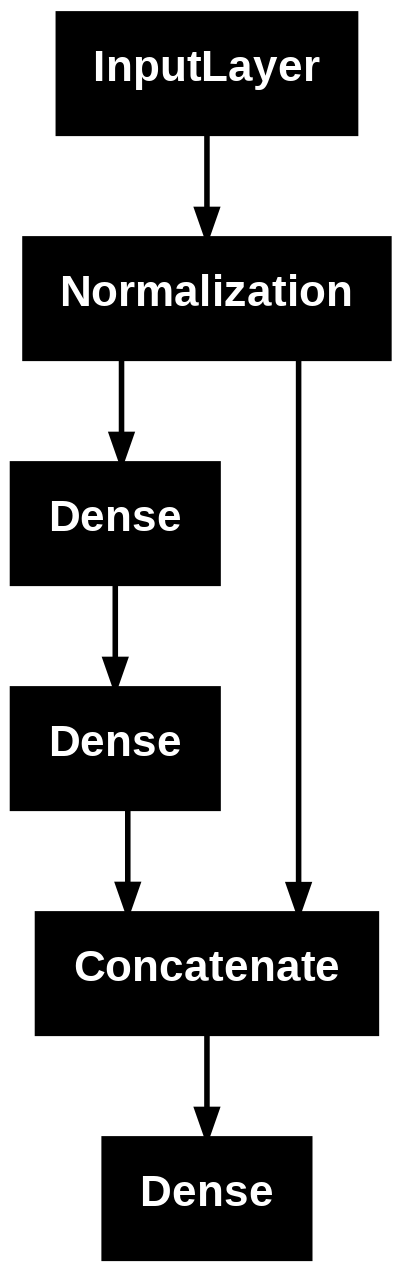

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
normalization_layer.adapt(X_train)

model.compile(
    loss='mse',
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=['RootMeanSquaredError']
)

model.fit(X_train,y_train,epochs=5,
          validation_data = (X_valid,y_valid))

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_10']
Received: inputs=Tensor(shape=(None, 8))
  warnings.warn(msg)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 1.2365 - loss: 1.6332 - val_RootMeanSquaredError: 1.5774 - val_loss: 2.4883
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.7593 - loss: 0.5769 - val_RootMeanSquaredError: 2.2212 - val_loss: 4.9337
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7063 - loss: 0.4991 - val_RootMeanSquaredError: 4.6350 - val_loss: 21.4829
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7094 - loss: 0.5047 - val_RootMeanSquaredError: 5.9807 - val_loss: 35.7685
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7305 - loss: 0.5395 - val_RootMeanSquaredError: 4.0299 - val_loss: 16.2398


In [ ]:
input_wide=tf.keras.layers.Input(shape=[5])
input_deep=tf.keras.layers.Input(shape=[6])
norm_layer_wide=tf.keras.layers.Normalization()
norm_layer_deep=tf.keras.layers.Normalization()
norm_wide=norm_layer_wide(input_wide)
norm_deep=norm_layer_deep(input_deep)
hidden1=tf.keras.layers.Dense(30,activation='relu')(norm_deep)
hidden2=tf.keras.layers.Dense(30,activation='relu')(hidden1)
concat=tf.keras.layers.concatenate([norm_wide,hidden2])
outputs=tf.keras.layers.Dense(1)(concat)
model=tf.keras.Model(inputs=[input_wide,input_deep],
                     outputs=[outputs])

In [ ]:
model.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['RootMeanSquaredError'])

X_train_wide,X_train_deep=X_train[:,:5], X_train[:,2:]
X_valid_wide,X_valid_deep=X_valid[:,:5], X_valid[:,2:]
X_test_wide,X_test_deep = X_test[:,:5],X_test[:,2:]
X_new_wide,X_new_deep = X_test_wide[:3],X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

history = model.fit((X_train_wide,X_train_deep),y_train,epochs=20,
                    validation_data=((X_valid_wide,X_valid_deep),y_valid))
mse_test=model.evaluate((X_test_wide,X_test_deep),y_test)
y_pred=model.predict((X_new_wide,X_new_deep))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 1.6710 - loss: 2.8745 - val_RootMeanSquaredError: 1.6873 - val_loss: 2.8469
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.7759 - loss: 0.6023 - val_RootMeanSquaredError: 0.7336 - val_loss: 0.5381
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 0.6958 - loss: 0.4844 - val_RootMeanSquaredError: 0.6420 - val_loss: 0.4122
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6585 - loss: 0.4338 - val_RootMeanSquaredError: 0.6140 - val_loss: 0.3770
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6400 - loss: 0.4098 - val_RootMeanSquaredError: 0.6597 - val_loss: 0.4351
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6298 - loss: 0.3967 - val_RootMeanSquaredError: 0.7056 - val_loss: 0.4979
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6229 - los

In [ ]:
input_wide=tf.keras.layers.Input(shape=[5])
input_deep=tf.keras.layers.Input(shape=[6])

norm_layer_wide=tf.keras.layers.Normalization()
norm_layer_deep=tf.keras.layers.Normalization()

norm_wide=norm_layer_deep(input_wide)
norm_deep=norm_layer_wide(input_deep)

hidden_1=tf.keras.layers.Dense(30,activation='relu')(norm_deep)
hidden_2=tf.keras.layers.Dense(30,activation='relu')(hidden1)
concat=tf.keras.layers.concatenate([hidden2,norm_wide])

output=tf.keras.layers.Dense(1)(concat)
aux_output=tf.keras.layers.Dense(1)(hidden2)

model=tf.keras.Model(inputs=[input_wide,input_deep],
                     outputs = [output,aux_output])



In [ ]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss=('mse','mse'), loss_weights=(0.9,0.1), optimizer=optimizer,
              metrics=['RootMeanSquaredError','RootMeanSquaredError']

)

In [ ]:
# norm_layer_wide.adapt(X_train_wide)
# norm_layer_deep.adapt(X_train_deep)

# history = model.fit(
#     (X_train_wide,X_train_deep),(y_train,y_train),epochs=20,
#     validation_data=((X_valid_wide,X_valid_deep),(y_valid,y_valid))
# )

ValueError: The layer was built with input_shape=(None, 6), but adapt() is being called with data with an incompatible shape, data.shape=(11610, 5)

# Using the Subclassing API to Build Dynamic Models

In [ ]:
@tf.keras.utils.register_keras_serializable()
class WideAndDeepModel(tf.keras.Model):
    def __init__(self,units=30,activation="relu",**kwargs):
        super().__init__(**kwargs)
        self.norm_layer_wide=tf.keras.layers.Normalization()
        self.norm_layer_deep=tf.keras.layers.Normalization()
        self.hidden1=tf.keras.layers.Dense(units,activation=activation)
        self.hidden2=tf.keras.layers.Dense(units,activation=activation)
        self.concat=tf.keras.layers.Concatenate()
        self.main_output=tf.keras.layers.Dense(1)
        self.aux_output=tf.keras.layers.Dense(1)
    def call(self,inputs):
        input_wide,input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1=self.hidden1(norm_deep)
        hidden2=self.hidden2(hidden1)
        concat=self.concat([norm_wide,hidden2])
        main_output=self.main_output(concat)
        aux_output=self.aux_output(hidden2)
        return main_output,aux_output
tf.random.set_seed(42)
model=WideAndDeepModel(30,activation='relu',name='my_wide_and_deep_model')

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss=['mse','mse'],loss_weights=[0.9,0.1],optimizer=optimizer,
              metrics=['RootMeanSquaredError','RootMeanSquaredError'])
model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)

history=model.fit(
    (X_train_wide,X_train_deep),(y_train,y_train),epochs=10,
    validation_data=((X_valid_wide,X_valid_deep),(y_valid,y_valid))
)
eval_results=model.evaluate((X_test_wide,X_test_deep),(y_test,y_test))
y_pred_main,y_pred_aux=model.predict((X_new_wide,X_new_deep))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 1.7840 - RootMeanSquaredError_1: 1.7259 - loss: 3.2718 - mse_loss: 3.0490 - val_RootMeanSquaredError: 2.0140 - val_RootMeanSquaredError_1: 1.2615 - val_loss: 3.8096 - val_mse_loss: 1.5908
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.7773 - RootMeanSquaredError_1: 0.8867 - loss: 0.6228 - mse_loss: 0.7877 - val_RootMeanSquaredError: 1.2528 - val_RootMeanSquaredError_1: 0.7663 - val_loss: 1.4713 - val_mse_loss: 0.5870
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.7057 - RootMeanSquaredError_1: 0.7659 - loss: 0.5070 - mse_loss: 0.5867 - val_RootMeanSquaredError: 0.8922 - val_RootMeanSquaredError_1: 0.8098 - val_loss: 0.7820 - val_mse_loss: 0.6557
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6720 - RootMeanSquaredError_1: 0.7418 - loss: 0.4616 - mse_loss: 0.5505 - val_RootMeanSquaredError: 0.7514 - val_RootMeanSquaredEr

# Saving and Restoring Model

In [ ]:
import shutil

shutil.rmtree('my_keras_model.keras',ignore_errors=True)

In [ ]:
model.save("my_keras_model.keras")

In [ ]:
model=tf.keras.models.load_model('/content/my_keras_model.keras')
y_pred_main,y_pred_aux =model.predict((X_new_wide,X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


In [ ]:
y_pred_main

array([[0.32538432],
       [1.3839039 ],
       [3.5354102 ]], dtype=float32)

# Using Callbacks

In [ ]:
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint('my_checkpoints.keras',
                                                 save_weights_only=False,
                                                 save_freq='epoch',
                                                 save_best_only=True)

history=model.fit((X_train_wide,X_train_deep),(y_train,y_train),epochs=10,
                  validation_data=((X_valid_wide,X_valid_deep),(y_valid,y_valid)),
                  callbacks=[checkpoint_cb])

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 63s 5ms/step - RootMeanSquaredError: 0.5964 - RootMeanSquaredError_1: 0.6643 - loss: 0.3643 - mse_loss: 0.4415 - val_RootMeanSquaredError: 0.6159 - val_RootMeanSquaredError_1: 0.6818 - val_loss: 0.3879 - val_mse_loss: 0.4647
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.5925 - RootMeanSquaredError_1: 0.6583 - loss: 0.3594 - mse_loss: 0.4336 - val_RootMeanSquaredError: 0.7567 - val_RootMeanSquaredError_1: 0.8753 - val_loss: 0.5919 - val_mse_loss: 0.7660
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5897 - RootMeanSquaredError_1: 0.6521 - loss: 0.3555 - mse_loss: 0.4254 - val_RootMeanSquaredError: 0.8847 - val_RootMeanSquaredError_1: 0.8672 - val_loss: 0.7797 - val_mse_loss: 0.7518
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.5894 - RootMeanSquaredError_1: 0.6526 - loss: 0.3553 - mse_loss: 0.4261 - val_RootMeanSquaredError: 0.9455 - val_RootMeanSquaredE

In [ ]:
early_stopping_cb=tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

history=model.fit((X_train_wide,X_train_deep),(y_train,y_train),epochs=100,
                  validation_data=((X_valid_wide,X_valid_deep),(y_valid,y_valid)),
                  callbacks=[checkpoint_cb,early_stopping_cb])

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5626 - RootMeanSquaredError_1: 0.6109 - loss: 0.3222 - mse_loss: 0.3733 - val_RootMeanSquaredError: 0.7149 - val_RootMeanSquaredError_1: 0.8253 - val_loss: 0.5281 - val_mse_loss: 0.6810
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.5620 - RootMeanSquaredError_1: 0.6107 - loss: 0.3215 - mse_loss: 0.3730 - val_RootMeanSquaredError: 0.8539 - val_RootMeanSquaredError_1: 0.9276 - val_loss: 0.7423 - val_mse_loss: 0.8602
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5610 - RootMeanSquaredError_1: 0.6076 - loss: 0.3202 - mse_loss: 0.3693 - val_RootMeanSquaredError: 0.6348 - val_RootMeanSquaredError_1: 0.6780 - val_loss: 0.4087 - val_mse_loss: 0.4596
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5600 - RootMeanSquaredError_1: 0.6084 - loss: 0.3192 - mse_loss: 0.3703 - val_RootMeanSquaredError: 0.7329 - val_RootMeanSquar

In [ ]:
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio=logs['val_loss']/logs['loss']
        print(f"Epoch={epoch}, val/train={ratio:.2f}")


In [ ]:
val_train_ratio_cb=PrintValTrainRatioCallback()
history=model.fit((X_train_wide,X_train_deep),(y_train,y_train),epochs=10,
                  validation_data=((X_valid_wide,X_valid_deep),(y_valid,y_valid)),
                  callbacks=[val_train_ratio_cb],verbose=0)

Epoch=0, val/train=1.15
Epoch=1, val/train=0.97
Epoch=2, val/train=2.26
Epoch=3, val/train=1.85
Epoch=4, val/train=1.58
Epoch=5, val/train=0.97
Epoch=6, val/train=1.39
Epoch=7, val/train=1.05
Epoch=8, val/train=1.52
Epoch=9, val/train=1.13
